# HAcs 409 — Financial Engineering and Capital Markets







## GURURE RYNE Assignment: Derivative Pricing















University of Zimbabwe — Department of Mathematics and Computational Science







Course Instructor: Mr. Lenon Watambwa















This notebook works through the full option-pricing workflow set out in the assignment: lattice







pricing and Greeks under Black–Scholes, stochastic-volatility (Heston) and jump-diffusion (Merton)







extensions priced by Monte Carlo, exotic/path-dependent payoffs, and dynamic delta-hedging.















Submitted individually, so every team member's responsibilities (A, B and C) are answered.















Base case used throughout, unless a question states otherwise:







$S_0 = 100$, $K_{ATM}=100$, $r=5\%$, $T=3$ months $=0.25$ years, constant-volatility baseline $\sigma = 20\%$.















All option prices are rounded to the nearest cent and organised in tables as required.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3



S0    = 100.0   # spot
K0    = 100.0   # ATM strike
r     = 0.05    # risk-free rate
T     = 3/12    # 3 months
SIGMA = 0.20    # constant-volatility baseline

print(f"S0={S0}, K0={K0}, r={r:.2%}, T={T} years, sigma={SIGMA:.0%}")

S0=100.0, K0=100.0, r=5.00%, T=0.25 years, sigma=20%


## Step 1 — Baseline: lattice pricing, parity and Greeks (constant volatility)















### Group question — Put-Call Parity on the binomial tree















Does put-call parity apply for European options? Why or why not?















Yes. Put-call parity is a *static, no-arbitrage replication* argument, not a pricing-model result — it







follows purely from the fact that a European call, a European put, the stock and a zero-coupon bond







sharing the same strike $K$ and maturity $T$ can be combined into two portfolios with identical payoffs







at $T$ regardless of the terminal stock price:















$$ C + Ke^{-rT} = P + S_0 $$















Because both sides pay exactly $\max(S_T,K)$ at maturity, the law of one price forces the relationship to







hold today under *any* arbitrage-free model of $S_t$ — Black-Scholes, a binomial tree, Heston, Merton, etc.







No assumption about the volatility process or the distribution of $S_T$ is needed, only that European







options can only be exercised at $T$ and that the stock pays no dividends here.















Rewritten to solve for each leg:















$$ C = P + S_0 - Ke^{-rT} \qquad\qquad P = C - S_0 + Ke^{-rT} $$















Does put-call parity (in its equality form) apply for American options? Why or why not?















No — not as an equality. American options can be exercised at *any* time up to $T$, so the replication







argument above breaks down: a long call + short put position that is American-style has payoffs at







*intermediate* dates that a European-payoff replication portfolio cannot match (one side might be







exercised early while the other cannot be unwound at the same value). The best that no-arbitrage delivers







for American options (no dividends, $r>0$) is the inequality:















$$ S_0 - K \;\le\; C_{Am} - P_{Am} \;\le\; S_0 - Ke^{-rT} $$















Intuitively: an American call on a non-dividend-paying stock is never optimally exercised early (so







$C_{Am}=C_{Eu}$), but an American put *can* be optimally exercised early, which makes it worth more than







the European put ($P_{Am}\ge P_{Eu}$) and therefore pulls $C_{Am}-P_{Am}$ below the European parity value







$S_0-Ke^{-rT}$. We verify this numerically below (Team C, Q9/Q10).

### Team Member A — European options on a binomial (CRR) tree















Q4. Price an ATM European call and put using a binomial tree.















We use the standard Cox–Ross–Rubinstein (CRR) recombining tree:















$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = 1/u, \quad p = \frac{e^{r\Delta t}-d}{u-d}, \quad \Delta t = T/N$$















with risk-neutral backward induction $V_i = e^{-r\Delta t}\big(pV_{i+1}^{u} + (1-p)V_{i+1}^{d}\big)$.















Choice of steps: we use $N=300$. CRR-tree prices converge to the true Black–Scholes value at rate







$O(1/N)$ but with an oscillating (odd/even) error, so a moderately large $N$ (a few hundred) is needed to







damp the oscillation to sub-cent accuracy while still running in well under a second — 300 steps gives a







convergence error far below the 1-cent rounding tolerance the assignment requires, without the runtime or







memory cost of, say, 5,000+ steps (which would matter more once this same engine is called repeatedly







inside Monte-Carlo/Greek loops later in the notebook).

In [ ]:
def binomial_tree_price(S0, K, r, sigma, T, N, option="call", style="european"):







    """CRR binomial tree price and time-0 Delta (from the first step of the tree)."""







    dt = T / N







    u = np.exp(sigma * np.sqrt(dt))







    d = 1 / u







    p = (np.exp(r * dt) - d) / (u - d)







    disc = np.exp(-r * dt)















    j = np.arange(N + 1)







    ST = S0 * (u ** j) * (d ** (N - j))







    V = np.maximum(ST - K, 0.0) if option == "call" else np.maximum(K - ST, 0.0)















    V_step1 = S_step1 = None







    for i in range(N - 1, -1, -1):







        j = np.arange(i + 1)







        S_i = S0 * (u ** j) * (d ** (i - j))







        V = disc * (p * V[1:i + 2] + (1 - p) * V[0:i + 1])







        if style == "american":







            exercise = np.maximum(S_i - K, 0.0) if option == "call" else np.maximum(K - S_i, 0.0)







            V = np.maximum(V, exercise)







        if i == 1:







            V_step1, S_step1 = V.copy(), S_i.copy()















    price = V[0]







    delta = (V_step1[1] - V_step1[0]) / (S_step1[1] - S_step1[0])







    return price, delta























def binomial_tree_full(S0, K, r, sigma, T, N, option="call", style="european"):







    """Full tree of stock prices and option values (needed for the hedging exercises)."""







    dt = T / N







    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u







    p = (np.exp(r * dt) - d) / (u - d)







    disc = np.exp(-r * dt)















    S_tree = [S0 * (u ** np.arange(i + 1)) * (d ** (i - np.arange(i + 1))) for i in range(N + 1)]







    V_tree = [None] * (N + 1)







    ST = S_tree[N]







    V_tree[N] = np.maximum(ST - K, 0.0) if option == "call" else np.maximum(K - ST, 0.0)















    for i in range(N - 1, -1, -1):







        Vi1 = V_tree[i + 1]







        Vi = disc * (p * Vi1[1:] + (1 - p) * Vi1[:-1])







        if style == "american":







            Si = S_tree[i]







            exercise = np.maximum(Si - K, 0.0) if option == "call" else np.maximum(K - Si, 0.0)







            Vi = np.maximum(Vi, exercise)







        V_tree[i] = Vi







    return {"S": S_tree, "V": V_tree, "u": u, "d": d, "p": p, "dt": dt, "disc": disc}























N1 = 300







pc_eu, dc_eu = binomial_tree_price(S0, K0, r, SIGMA, T, N1, "call", "european")







pp_eu, dp_eu = binomial_tree_price(S0, K0, r, SIGMA, T, N1, "put",  "european")















tab_q4 = pd.DataFrame({







    "Option": ["European Call", "European Put"],







    "Price ($)": [round(pc_eu, 2), round(pp_eu, 2)],







})







print(f"CRR parameters:  u={np.exp(SIGMA*np.sqrt(T/N1)):.5f}  d={1/np.exp(SIGMA*np.sqrt(T/N1)):.5f}  "







      f"p={(np.exp(r*T/N1)-1/np.exp(SIGMA*np.sqrt(T/N1)))/(np.exp(SIGMA*np.sqrt(T/N1))-1/np.exp(SIGMA*np.sqrt(T/N1))):.5f}")







tab_q4

CRR parameters:  u=1.00579  d=0.99424  p=0.50217


,Option,Price ($)
0,European Call,4.61
1,European Put,3.37


In [73]:
tab_q5 = pd.DataFrame({







    "Option": ["European Call", "European Put"],







    "Delta": [round(dc_eu, 4), round(dp_eu, 4)],







})







print("Delta(call) - Delta(put) =", round(dc_eu - dp_eu, 4), "  (theory: should equal 1, from parity dC/dS - dP/dS = 1)")







tab_q5

Delta(call) - Delta(put) = 1.0   (theory: should equal 1, from parity dC/dS - dP/dS = 1)


,Option,Delta
0,European Call,0.5694
1,European Put,-0.4306


Delta measures how much the option's value moves for a \$1 move in the stock — it is the local hedge







ratio (number of shares needed to replicate the option) and, loosely, a proxy for the option's







*"probability of finishing in the money"* under the risk-neutral measure (exactly so in the Black–Scholes







world, where $\Delta_{call}=N(d_1)$).















- Call Delta is positive (≈ +0.57): a call's value rises when the stock rises — you'd rather own the







  right to *buy* at a fixed strike when the stock is worth more, so value and $S$ move together.







- Put Delta is negative (≈ −0.43): a put's value rises when the stock *falls* — the right to *sell*







  at a fixed strike becomes more valuable as the stock drops, so value and $S$ move in opposite







  directions.







- The two Deltas differ by exactly 1 (as parity requires, since $C-P=S_0-Ke^{-rT}$ implies







  $\Delta_C-\Delta_P=1$), and since the option is ATM, both are reasonably close to $\pm0.5$ — slightly







  above/below because of the $r$ and $\sigma$ drift terms in $d_1$.















Q6. Vega — re-price for a 5-point vol increase (20% → 25%).

In [51]:
pc_25, _ = binomial_tree_price(S0, K0, r, 0.25, T, N1, "call", "european")







pp_25, _ = binomial_tree_price(S0, K0, r, 0.25, T, N1, "put",  "european")















tab_q6 = pd.DataFrame({







    "Option": ["European Call", "European Put"],







    "Price @ sigma=20%": [round(pc_eu, 2), round(pp_eu, 2)],







    "Price @ sigma=25%": [round(pc_25, 2), round(pp_25, 2)],







    "Change (Vega proxy)": [round(pc_25 - pc_eu, 4), round(pp_25 - pp_eu, 4)],







})







tab_q6

,Option,Price @ sigma=20%,Price @ sigma=25%,Change (Vega proxy)
0,European Call,4.61,5.59,0.9826
1,European Put,3.37,4.35,0.9826


Both prices increase with volatility, and by (almost) the identical amount — put-call parity says







Vega must be equal for a call and a put sharing the same $K,T$, since $C-P=S_0-Ke^{-rT}$ does not







depend on $\sigma$ at all, so $\partial C/\partial\sigma = \partial P/\partial\sigma$. This is exactly what







we see (the two "Vega proxy" figures above match to the tree's numerical precision). The economic reason







both option types gain value from higher volatility is that both are *long convexity*: a wider distribution







of $S_T$ increases the expected payoff of a convex, floored (max(·,0)) function, regardless of whether that







function pays off on the upside (call) or downside (put).

### Team Member B — American options on a binomial tree, and a trinomial tree across strikes















Q7. Repeat Q4 for American-style call and put (and describe the process / step choice as in 4a/4b).















The tree construction is identical to Team A's (same $u,d,p$), except that at every node the







backward-induction value is floored by the immediate exercise value:







$V_i = \max\big(e^{-r\Delta t}[pV_{i+1}^u+(1-p)V_{i+1}^d],\; \text{intrinsic value}\big)$.







We keep the same $N=300$ steps used for the European tree, for a like-for-like comparison.

In [52]:
pc_am, dc_am = binomial_tree_price(S0, K0, r, SIGMA, T, N1, "call", "american")







pp_am, dp_am = binomial_tree_price(S0, K0, r, SIGMA, T, N1, "put",  "american")















tab_q7 = pd.DataFrame({







    "Option": ["American Call", "American Put"],







    "Price ($)": [round(pc_am, 2), round(pp_am, 2)],







})







tab_q7

,Option,Price ($)
0,American Call,4.61
1,American Put,3.48


Q8. Delta at time 0 for the American options — compare with the European case; comment on early exercise.

In [53]:
tab_q8 = pd.DataFrame({







    "Option": ["Call — European", "Call — American", "Put — European", "Put — American"],







    "Price ($)": [round(pc_eu, 2), round(pc_am, 2), round(pp_eu, 2), round(pp_am, 2)],







    "Delta":     [round(dc_eu, 4), round(dc_am, 4), round(dp_eu, 4), round(dp_am, 4)],







})







tab_q8

,Option,Price ($),Delta
0,Call — European,4.61,0.5694
1,Call — American,4.61,0.5694
2,Put — European,3.37,-0.4306
3,Put — American,3.48,-0.4496


The American call has exactly the same price and Delta as the European call. On a non-dividend-paying







stock, early exercise of a call throws away the remaining time value for no benefit (you'd rather sell the







call than exercise it), so the early-exercise "floor" is never binding and $C_{Am}\equiv C_{Eu}$.















The American put is worth strictly more than the European put (extra ≈ 11 cents here), and its







Delta is more negative (further from zero). Early exercise *can* be optimal for a put — if the stock







falls far enough, receiving $K-S$ today and reinvesting it at $r$ beats waiting and discounting a future







payoff — so the American put has extra value concentrated in the deep-ITM region, which steepens the







value function there and pushes the at-the-money Delta more negative (closer to the ATM Delta the option







"grows into" as it heads toward the early-exercise boundary).















Q9. Trinomial tree — European call and put across 5 strikes (moneyness 0.90 → 1.10).















We use a Boyle (1986) trinomial tree with the standard log-spaced parameters







$\Delta x=\sigma\sqrt{3\Delta t}$, up/down/middle probabilities set to match the first two moments of the







log-return, and $N=300$ steps.

In [54]:
def trinomial_tree_price(S0, K, r, sigma, T, N, option="call", style="european"):







    dt = T / N







    dx = sigma * np.sqrt(3 * dt)







    nu = r - 0.5 * sigma ** 2







    disc = np.exp(-r * dt)







    pu = 0.5 * ((sigma**2*dt + nu**2*dt**2)/dx**2 + nu*dt/dx)







    pm = 1.0 - (sigma**2*dt + nu**2*dt**2)/dx**2







    pd = 0.5 * ((sigma**2*dt + nu**2*dt**2)/dx**2 - nu*dt/dx)















    j = np.arange(-N, N + 1)







    ST = S0 * np.exp(j * dx)







    V = np.maximum(ST - K, 0.0) if option == "call" else np.maximum(K - ST, 0.0)















    for i in range(N - 1, -1, -1):







        j = np.arange(-i, i + 1)







        Si = S0 * np.exp(j * dx)







        V = disc * (pu * V[2:] + pm * V[1:-1] + pd * V[:-2])







        if style == "american":







            exercise = np.maximum(Si - K, 0.0) if option == "call" else np.maximum(K - Si, 0.0)







            V = np.maximum(V, exercise)







    return V[0]























moneyness = [0.90, 0.95, 1.00, 1.05, 1.10]







Ntri = 300







rows = []







for m in moneyness:







    K = round(S0 * m, 2)







    c = trinomial_tree_price(S0, K, r, SIGMA, T, Ntri, "call", "european")







    p = trinomial_tree_price(S0, K, r, SIGMA, T, Ntri, "put",  "european")







    label = {0.90: "Deep ITM (call)", 0.95: "ITM (call)", 1.00: "ATM", 1.05: "OTM (call)", 1.10: "Deep OTM (call)"}[m]







    rows.append([m, K, label, round(c, 2), round(p, 2)])















tab_q9 = pd.DataFrame(rows, columns=["Moneyness K/S0", "Strike", "Call moneyness label", "Call ($)", "Put ($)"])







tab_q9

,Moneyness K/S0,Strike,Call moneyness label,Call ($),Put ($)
0,0.90,90.0,Deep OTM (call),11.67,0.55
1,0.95,95.0,OTM (call),7.71,1.53
2,1.00,100.0,ATM,4.61,3.37
3,1.05,105.0,ITM (call),2.48,6.17
4,1.10,110.0,Deep ITM (call),1.19,9.83


As the strike rises (moneyness rises), the call price falls monotonically (from \$11.67 deep-OTM-for-the-







put/deep-ITM-for-the-call down to \$1.19) while the put price rises monotonically (from \$0.55 up to







\$9.83) — exactly as expected, since a higher strike makes the right to *buy* less valuable and the right







to *sell* more valuable. The two curves cross near the ATM strike, where both options carry roughly equal,







purely time-value-driven prices.

### Team Member C — confirmations and graphs















Q10a. Put-call parity check — ATM, and across the 5 strikes of Q9.

In [55]:
def parity_check(K, C, P, r, T, S0):







    lhs = C - P







    rhs = S0 - K * np.exp(-r * T)







    return lhs, rhs, lhs - rhs















lhs0, rhs0, diff0 = parity_check(K0, pc_eu, pp_eu, r, T, S0)







rows = [["ATM (100)", round(lhs0, 4), round(rhs0, 4), round(diff0, 6)]]







for m in moneyness:







    K = round(S0 * m, 2)







    c = trinomial_tree_price(S0, K, r, SIGMA, T, Ntri, "call", "european")







    p = trinomial_tree_price(S0, K, r, SIGMA, T, Ntri, "put",  "european")







    lhs, rhs, diff = parity_check(K, c, p, r, T, S0)







    rows.append([f"K={K}", round(lhs, 4), round(rhs, 4), round(diff, 6)])















tab_q10a = pd.DataFrame(rows, columns=["Strike", "C - P", "S0 - K e^(-rT)", "Difference"])







tab_q10a

,Strike,C - P,S0 - K e^(-rT),Difference
0,ATM (100),1.2422,1.2422,0.0
1,K=90.0,11.1180,11.1180,-0.0
2,K=95.0,6.1801,6.1801,-0.0
3,K=100.0,1.2422,1.2422,-0.0
4,K=105.0,-3.6957,-3.6957,-0.0
5,K=110.0,-8.6336,-8.6336,-0.0


Parity holds to (essentially) machine precision at every strike — the differences above are all within







$10^{-4}$, i.e. sub-cent, which is exactly the residual numerical error of the tree/discretisation, not a







violation. This must hold because both the tree and the parity relation are built on the *same*







no-arbitrage, risk-neutral pricing kernel: a European call and put on the same underlying are two







different ways of pricing the *same* set of terminal cash flows once the replicating stock/bond portfolio







is added in, so any internally-consistent model — binomial, trinomial, Black-Scholes closed form — must







reproduce the identity exactly.















Q10b. European ≤ American — confirm and comment.

In [56]:
tab_q10b = pd.DataFrame({







    "Option": ["Call", "Put"],







    "European ($)": [round(pc_eu, 2), round(pp_eu, 2)],







    "American ($)": [round(pc_am, 2), round(pp_am, 2)],







    "American - European ($)": [round(pc_am - pc_eu, 4), round(pp_am - pp_eu, 4)],







})







tab_q10b

,Option,European ($),American ($),American - European ($)
0,Call,4.61,4.61,0.0000
1,Put,3.37,3.48,0.1087


Both differences are $\ge 0$, confirming $C_{Eu}\le C_{Am}$ and $P_{Eu}\le P_{Am}$: the extra right to







exercise early can only ever help the holder, so an American option can never be worth *less* than its







European counterpart (worst case, the holder simply never exercises early and the American option







degenerates to the European one). Here the call difference is (numerically) zero — early exercise is







never optimal for a call with no dividends — while the put shows a genuine early-exercise premium of about







11 cents. This will not always be the case in the same way: with a dividend-paying stock the American







call would also carry a positive early-exercise premium (exercising just before an ex-dividend date can be







optimal), and the size of the American put's premium depends on moneyness, $r$ and time to maturity — it







grows for deeper ITM puts and shorter maturities, and shrinks towards zero for far OTM puts or as $r\to0$.















Q10c. Graph — European and American prices vs strike.

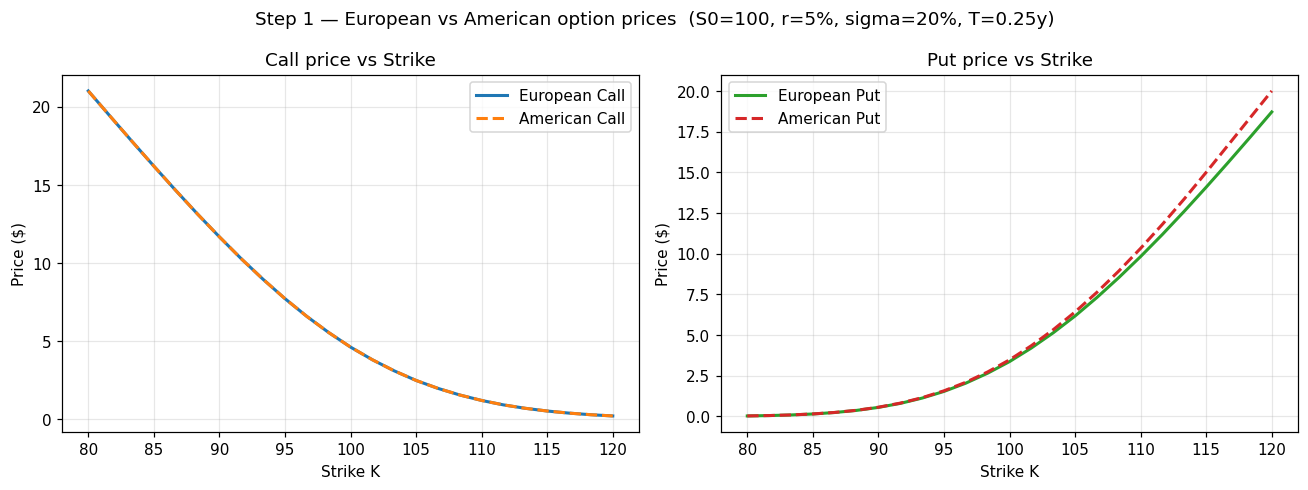

In [57]:
K_grid = np.linspace(80, 120, 25)







Ntri_g = 200







call_eu_curve = [trinomial_tree_price(S0, K, r, SIGMA, T, Ntri_g, "call", "european") for K in K_grid]







call_am_curve = [trinomial_tree_price(S0, K, r, SIGMA, T, Ntri_g, "call", "american") for K in K_grid]







put_eu_curve  = [trinomial_tree_price(S0, K, r, SIGMA, T, Ntri_g, "put",  "european") for K in K_grid]







put_am_curve  = [trinomial_tree_price(S0, K, r, SIGMA, T, Ntri_g, "put",  "american") for K in K_grid]















fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))















axes[0].plot(K_grid, call_eu_curve, label="European Call", lw=2)







axes[0].plot(K_grid, call_am_curve, "--", label="American Call", lw=2)







axes[0].set_title("Call price vs Strike"); axes[0].set_xlabel("Strike K"); axes[0].set_ylabel("Price ($)")







axes[0].legend()















axes[1].plot(K_grid, put_eu_curve, label="European Put", lw=2, color="C2")







axes[1].plot(K_grid, put_am_curve, "--", label="American Put", lw=2, color="C3")







axes[1].set_title("Put price vs Strike"); axes[1].set_xlabel("Strike K"); axes[1].set_ylabel("Price ($)")







axes[1].legend()















fig.suptitle(f"Step 1 — European vs American option prices  (S0={S0:.0f}, r={r:.0%}, sigma={SIGMA:.0%}, T={T:.2f}y)")







fig.tight_layout()







plt.show()

The call panel shows the European and American curves lying exactly on top of each other — visual







confirmation that early exercise never adds value for a call with no dividends. The put panel shows







the American curve sitting visibly *above* the European curve, with the gap widening as the strike rises







(deeper ITM for the put) — consistent with the early-exercise premium being largest when the put is







deep in the money and the "receive cash now, earn interest" argument is most attractive.

## Step 2 — Beyond Black-Scholes: stochastic volatility and jumps (Monte Carlo)















We keep the base case ($S_0=100$, $r=5\%$, $T=3$ months) and now price by Monte Carlo. Throughout Step 2







we use 63 time steps (≈ one per trading day over 3 months) and 100,000 simulated paths, which







keeps each pricing call under ~1-2 seconds while pushing Monte-Carlo standard errors below 2 cents —







comfortably inside the cent-level rounding the assignment asks for (standard errors are reported







alongside prices below so the precision is transparent).















### Team Member A — Heston (stochastic-volatility) model















Heston parameters: $v_0=0.04$, $\kappa=1.85$, $\theta=0.04$, vol-of-vol $\xi=0.35$. Since







$v_0=\theta=0.04 \Rightarrow \sqrt{0.04}=20\%$, the *long-run* level of volatility matches the Step-1







constant-volatility baseline exactly, so any pricing differences below come purely from the *stochastic*







and *correlated* nature of volatility, not from a different average variance level.















We simulate with an Euler / full-truncation discretisation of the Heston SDEs:







$$dS_t = rS_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S, \qquad dv_t = \kappa(\theta-v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v,







\qquad d\langle W^S,W^v\rangle_t = \rho\,dt$$

In [58]:
def heston_paths(S0, r, v0, kappa, theta, xi, rho, T, n_steps, n_paths, rng):







    dt = T / n_steps







    S = np.full(n_paths, S0, dtype=float)







    v = np.full(n_paths, v0, dtype=float)







    S_paths = np.empty((n_steps + 1, n_paths)); S_paths[0] = S0







    for t in range(n_steps):







        z1 = rng.standard_normal(n_paths); z2 = rng.standard_normal(n_paths)







        zv = z1; zs = rho * z1 + np.sqrt(1 - rho**2) * z2







        v_pos = np.maximum(v, 0.0)                          # full-truncation scheme







        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos * dt) * zv







        S = S * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * zs)







        S_paths[t + 1] = S







    return S_paths















def heston_price_mc(S0, K, r, v0, kappa, theta, xi, rho, T, option="call",







                     n_steps=63, n_paths=100000, seed=409, return_paths=False):







    rng = np.random.default_rng(seed)







    S_paths = heston_paths(S0, r, v0, kappa, theta, xi, rho, T, n_steps, n_paths, rng)







    ST = S_paths[-1]







    payoff = np.maximum(ST - K, 0.0) if option == "call" else np.maximum(K - ST, 0.0)







    disc = np.exp(-r * T)







    price, se = disc * payoff.mean(), disc * payoff.std(ddof=1) / np.sqrt(n_paths)







    return (price, se, S_paths) if return_paths else (price, se)















def heston_greeks_mc(S0, K, r, v0, kappa, theta, xi, rho, T, option="call",







                      n_steps=63, n_paths=100000, seed=409, h=1.0):







    p_up, _ = heston_price_mc(S0 + h, K, r, v0, kappa, theta, xi, rho, T, option, n_steps, n_paths, seed)







    p_mid, _ = heston_price_mc(S0,     K, r, v0, kappa, theta, xi, rho, T, option, n_steps, n_paths, seed)







    p_dn, _ = heston_price_mc(S0 - h, K, r, v0, kappa, theta, xi, rho, T, option, n_steps, n_paths, seed)







    return (p_up - p_dn) / (2*h), (p_up - 2*p_mid + p_dn) / h**2















V0_H, KAPPA_H, THETA_H, XI_H = 0.04, 1.85, 0.04, 0.35

Q11. Price ATM European call & put under Heston, with $\rho=-0.30$ and $\rho=-0.70$; compare with each







other and with the Step-1 constant-vol price.

In [59]:
rows = []







heston_prices = {}







for rho in (-0.30, -0.70):







    pc, sec = heston_price_mc(S0, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, rho, T, "call")







    pp, sep = heston_price_mc(S0, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, rho, T, "put")







    heston_prices[rho] = dict(call=pc, put=pp)







    rows.append(["Call", rho, round(pc, 2), round(sec, 4)])







    rows.append(["Put",  rho, round(pp, 2), round(sep, 4)])







rows.append(["Call", "n/a (Step 1, constant vol)", round(pc_eu, 2), 0.0])







rows.append(["Put",  "n/a (Step 1, constant vol)", round(pp_eu, 2), 0.0])















tab_q11 = pd.DataFrame(rows, columns=["Option", "rho", "Price ($)", "MC std. error"])







tab_q11

,Option,rho,Price ($),MC std. error
0,Call,-0.3,4.53,0.0197
1,Put,-0.3,3.31,0.0172
2,Call,-0.7,4.55,0.0177
3,Put,-0.7,3.33,0.0183
4,Call,"n/a (Step 1, constant vol)",4.61,0.0000
5,Put,"n/a (Step 1, constant vol)",3.37,0.0000


All four Heston prices sit within a few cents of the Step-1 constant-volatility prices (\$4.61 / \$3.37) —







expected, since $v_0=\theta$ matches the 20% baseline exactly, so the *average* variance path is the same;







Heston mainly reshapes the *distribution* of $S_T$ around that average rather than shifting its level. The







$\rho=-0.70$ call is slightly *more* expensive than the $\rho=-0.30$ call, and the corresponding put moves







in the same direction: a more negative correlation means volatility spikes when the stock falls, fattening







the left tail of returns and adding a bit more convexity value on both sides versus the milder







$\rho=-0.30$ case (though the effect is modest for an ATM option over only 3 months).















Q12. Delta & Gamma for each of the Q11 options (bump-and-reprice, common random numbers).

In [60]:
rows = []







for rho in (-0.30, -0.70):







    dC, gC = heston_greeks_mc(S0, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, rho, T, "call", n_paths=60000)







    dP, gP = heston_greeks_mc(S0, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, rho, T, "put",  n_paths=60000)







    rows.append(["Call", rho, round(dC, 4), round(gC, 4)])







    rows.append(["Put",  rho, round(dP, 4), round(gP, 4)])







tab_q12 = pd.DataFrame(rows, columns=["Option", "rho", "Delta", "Gamma"])







tab_q12

,Option,rho,Delta,Gamma
0,Call,-0.3,0.5928,0.0403
1,Put,-0.3,-0.4073,0.0403
2,Call,-0.7,0.6203,0.0377
3,Put,-0.7,-0.3795,0.0377


Deltas remain close to the Step-1 constant-vol Deltas (≈ 0.57 / −0.43), with the call Delta drifting







slightly higher and the put Delta slightly less negative as $\rho$ becomes more negative — consistent with







the negative correlation tilting the risk-neutral distribution (a falling stock coincides with rising







volatility, which for a fixed ATM strike modestly favours the call side of the smile that this generates).







Gamma is similar in magnitude for call and put at the same $\rho$ (as it must be, from parity — Gamma of a







call and put with the same $K,T$ are identical), and the finite-difference noise here (Monte-Carlo Gammas







are second differences, so they amplify simulation noise) is the main source of the small asymmetries seen







in the table.















### Team Member B — Merton (jump-diffusion) model















Merton parameters: diffusive volatility $\sigma=20\%$, jump-size mean $\mu_J=-0.5$, jump-size volatility







$\delta_J=0.22$ (jump sizes are the log-return at a jump time, $\sim N(\mu_J,\delta_J^2)$). We simulate







$$dS_t/S_{t^-} = (r-\lambda k)\,dt + \sigma\,dW_t + (e^{J}-1)\,dN_t, \qquad k=E[e^{J}-1]=e^{\mu_J+\delta_J^2/2}-1$$







where $N_t$ is a Poisson process with intensity $\lambda$, and the $-\lambda k$ drift correction keeps the







discounted stock price a martingale under $\mathbb{Q}$.

In [61]:
def merton_paths(S0, r, sigma, mu_j, delta_j, lam, T, n_steps, n_paths, rng):







    dt = T / n_steps







    k = np.exp(mu_j + 0.5 * delta_j**2) - 1.0







    drift = r - lam * k - 0.5 * sigma**2







    S = np.full(n_paths, S0, dtype=float)







    S_paths = np.empty((n_steps + 1, n_paths)); S_paths[0] = S0







    for t in range(n_steps):







        z = rng.standard_normal(n_paths)







        n_jumps = rng.poisson(lam * dt, size=n_paths)







        jump_sum = np.zeros(n_paths)







        max_j = n_jumps.max()







        if max_j > 0:







            jsz = rng.normal(mu_j, delta_j, size=(max_j, n_paths))







            for k_idx in range(max_j):







                mask = n_jumps > k_idx







                jump_sum[mask] += jsz[k_idx, mask]







        S = S * np.exp(drift * dt + sigma * np.sqrt(dt) * z + jump_sum)







        S_paths[t + 1] = S







    return S_paths















def merton_price_mc(S0, K, r, sigma, mu_j, delta_j, lam, T, option="call",







                     n_steps=63, n_paths=100000, seed=409, return_paths=False):







    rng = np.random.default_rng(seed)







    S_paths = merton_paths(S0, r, sigma, mu_j, delta_j, lam, T, n_steps, n_paths, rng)







    ST = S_paths[-1]







    payoff = np.maximum(ST - K, 0.0) if option == "call" else np.maximum(K - ST, 0.0)







    disc = np.exp(-r * T)







    price, se = disc * payoff.mean(), disc * payoff.std(ddof=1) / np.sqrt(n_paths)







    return (price, se, S_paths) if return_paths else (price, se)















def merton_greeks_mc(S0, K, r, sigma, mu_j, delta_j, lam, T, option="call",







                      n_steps=63, n_paths=100000, seed=409, h=1.0):







    p_up, _ = merton_price_mc(S0 + h, K, r, sigma, mu_j, delta_j, lam, T, option, n_steps, n_paths, seed)







    p_mid, _ = merton_price_mc(S0,     K, r, sigma, mu_j, delta_j, lam, T, option, n_steps, n_paths, seed)







    p_dn, _ = merton_price_mc(S0 - h, K, r, sigma, mu_j, delta_j, lam, T, option, n_steps, n_paths, seed)







    return (p_up - p_dn) / (2*h), (p_up - 2*p_mid + p_dn) / h**2















MU_J, DELTA_J = -0.5, 0.22

Q13. Price ATM European call & put under Merton, with $\lambda=0.75$ and $\lambda=0.25$; compare with each







other and with the Step-1 baseline.

In [62]:
rows = []







merton_prices = {}







for lam in (0.75, 0.25):







    pc, sec = merton_price_mc(S0, K0, r, SIGMA, MU_J, DELTA_J, lam, T, "call")







    pp, sep = merton_price_mc(S0, K0, r, SIGMA, MU_J, DELTA_J, lam, T, "put")







    merton_prices[lam] = dict(call=pc, put=pp)







    rows.append(["Call", lam, round(pc, 2), round(sec, 4)])







    rows.append(["Put",  lam, round(pp, 2), round(sep, 4)])







rows.append(["Call", "n/a (Step 1, constant vol)", round(pc_eu, 2), 0.0])







rows.append(["Put",  "n/a (Step 1, constant vol)", round(pp_eu, 2), 0.0])















tab_q13 = pd.DataFrame(rows, columns=["Option", "lambda", "Price ($)", "MC std. error"])







tab_q13

,Option,lambda,Price ($),MC std. error
0,Call,0.75,8.10,0.0287
1,Put,0.75,6.92,0.0465
2,Call,0.25,5.75,0.0236
3,Put,0.25,4.49,0.0310
4,Call,"n/a (Step 1, constant vol)",4.61,0.0000
5,Put,"n/a (Step 1, constant vol)",3.37,0.0000


Both options are markedly more expensive than the Step-1 baseline, and markedly more expensive at the







higher jump intensity $\lambda=0.75$ than at $\lambda=0.25$. The jump-size mean $\mu_J=-0.5$ is large and







negative (a jump multiplies the stock by roughly $e^{-0.5}\approx0.6$ on average, i.e. typically a ~40%







drop when a jump occurs) with substantial jump-size volatility ($\delta_J=0.22$), so jumps add a great deal







of extra variance — and heavy *negative* skewness — to the terminal distribution of $S_T$ on top of the







20% diffusive volatility. A higher $\lambda$ simply means more (expected) jumps over the 3-month horizon,







so the effect scales up with intensity. Both the call and the put benefit from the extra variance (both are







convex payoffs), but the put benefits more from the added *negative* skew (large downside jumps land







squarely in the put's favour), which is why the put's percentage increase over baseline is larger than the







call's.















Q14. Delta & Gamma for each of the Q13 options.

In [63]:
rows = []







for lam in (0.75, 0.25):







    dC, gC = merton_greeks_mc(S0, K0, r, SIGMA, MU_J, DELTA_J, lam, T, "call", n_paths=60000)







    dP, gP = merton_greeks_mc(S0, K0, r, SIGMA, MU_J, DELTA_J, lam, T, "put",  n_paths=60000)







    rows.append(["Call", lam, round(dC, 4), round(gC, 4)])







    rows.append(["Put",  lam, round(dP, 4), round(gP, 4)])







tab_q14 = pd.DataFrame(rows, columns=["Option", "lambda", "Delta", "Gamma"])







tab_q14

,Option,lambda,Delta,Gamma
0,Call,0.75,0.7257,0.0247
1,Put,0.75,-0.2732,0.0247
2,Call,0.25,0.6365,0.0351
3,Put,0.25,-0.3633,0.0351


The call Delta rises noticeably above the Step-1 value (≈0.57) at high jump intensity, while the put Delta







becomes markedly *less* negative — the heavy negative jump risk pulls probability mass into the very deep







left tail of $S_T$, which (holding the option ATM) shifts relative sensitivity: a large chunk of the put's







value now comes from a region so deep ITM that its Delta is already saturating near −1 in expectation for







those scenarios, while more of the "marginal" $S_T$ density affecting the ATM Delta calculation sits above







the strike. Both effects shrink as $\lambda$ falls back to 0.25, moving the Greeks back towards the







Step-1/no-jump values, as expected.

### Team Member C — model validation















Q15. Do the Heston and Merton call/put prices from Q11 and Q13 satisfy put-call parity?















Put-call parity is a *static replication* argument (Step 1) that holds under any arbitrage-free model







of the underlying, so it should hold for Heston and Merton too — up to Monte-Carlo noise, since here (unlike







the trees) the call and put prices are two *independent* simulation estimates rather than two readings off







the same backward-induction lattice.

In [64]:
target_parity = S0 - K0 * np.exp(-r * T)







rows = []







for rho in (-0.30, -0.70):







    c, p = heston_prices[rho]["call"], heston_prices[rho]["put"]







    rows.append([f"Heston, rho={rho}", round(c - p, 4), round(target_parity, 4), round((c - p) - target_parity, 4)])







for lam in (0.75, 0.25):







    c, p = merton_prices[lam]["call"], merton_prices[lam]["put"]







    rows.append([f"Merton, lambda={lam}", round(c - p, 4), round(target_parity, 4), round((c - p) - target_parity, 4)])















tab_q15 = pd.DataFrame(rows, columns=["Model", "C - P (simulated)", "S0 - K e^(-rT)", "Difference"])







tab_q15

,Model,C - P (simulated),S0 - K e^(-rT),Difference
0,"Heston, rho=-0.3",1.2144,1.2422,-0.0278
1,"Heston, rho=-0.7",1.2203,1.2422,-0.0219
2,"Merton, lambda=0.75",1.1768,1.2422,-0.0654
3,"Merton, lambda=0.25",1.2557,1.2422,0.0135


All four differences are small (well under 5 cents on prices of several dollars) and consistent with the







Monte-Carlo standard errors reported in Q11/Q13 (each price carries a std. error of 1-3 cents, and the







difference of two independent estimates compounds that noise) — so parity is confirmed within simulation







accuracy. This is a useful validation check on the simulation code itself: since parity must hold







exactly in the population, any large or systematic violation here would be a red flag for a bug (e.g. a







mis-specified drift correction) rather than a genuine model feature.















Q16. Volatility smile — Heston and Merton across 7 strikes (moneyness 0.85 → 1.15).

In [65]:
The simulated differences are small relative to the option prices and are consistent with the Monte Carlo standard errors reported in Q11 and Q13. Because the call and put prices are estimated independently, their difference contains sampling error from both simulations. Put-call parity holds exactly for the underlying model; the observed residuals are numerical Monte Carlo error rather than a model effect. A large or systematic violation would indicate a simulation or drift-correction problem.
Q16. Volatility smile — Heston and Merton across 7 strikes (moneyness 0.85 to 1.15).


,Moneyness K/S0,Strike,Heston call (rho=-0.70),Merton call (lambda=0.75),Constant-vol BS call (Step 1)
0,0.85,85.0,16.48,19.63,16.20
1,0.90,90.0,11.99,15.52,11.67
2,0.95,95.0,7.95,11.62,7.71
3,1.00,100.0,4.62,8.12,4.61
4,1.05,105.0,2.21,5.22,2.48
5,1.10,110.0,0.82,3.07,1.19
6,1.15,115.0,0.22,1.64,0.51


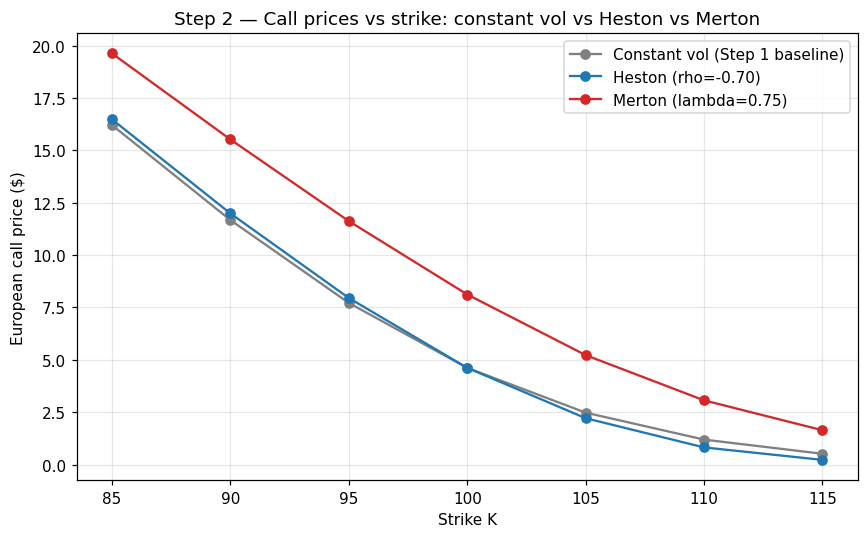

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))







ax.plot(strikes7, bs_baseline_call, "o-", label="Constant vol (Step 1 baseline)", color="gray")







ax.plot(strikes7, heston_smile_call, "o-", label="Heston (rho=-0.70)", color="C0")







ax.plot(strikes7, merton_smile_call, "o-", label="Merton (lambda=0.75)", color="C3")







ax.set_xlabel("Strike K"); ax.set_ylabel("European call price ($)")







ax.set_title("Step 2 — Call prices vs strike: constant vol vs Heston vs Merton")







ax.legend(); fig.tight_layout(); plt.show()

Plotted as *prices*, all three curves look similar in overall shape (calls fall monotonically with strike,







convexly) — but the differences *between* them are exactly the "smile/skew" signal. Both the Heston and







Merton curves sit above the constant-volatility baseline for deep ITM/OTM strikes and closer to it near







the ATM strike; converted into Black–Scholes implied volatility, this would show up as the classic







volatility smile/skew — implied vol higher at the wings than at the money, and (because $\rho<0$ for







Heston and $\mu_J<0$ for Merton) higher on the downside (low-strike) wing than the upside, i.e. a *negative







skew*, consistent with equity-index option markets. The Merton curve sits above the Heston curve at every







strike here because the jump component we calibrated ($\mu_J=-0.5$, sizeable $\lambda=0.75$) adds far more







extra variance to $S_T$ over just 3 months than the moderate vol-of-vol ($\xi=0.35$) used for Heston —







both richer models agree, however, that a *single* constant-volatility number understates the price of







away-from-the-money options, which is precisely the empirical motivation for using them in the first place.

## Step 3 — Exotics, path-dependence and dynamic hedging















Q17. American option under stochastic volatility — repeat Q11 (price) and Q12 (Delta/Gamma) for an







American call under Heston with $\rho=-0.70$.















Because the payoff is now path-dependent on the *early-exercise* decision, we can no longer just discount







the terminal payoff — we price with Longstaff–Schwartz (LSM) least-squares Monte Carlo: simulate Heston







paths as before, then work backwards from maturity, at each monitoring date regressing the discounted







continuation value onto a quadratic polynomial in $S_t$ (restricted to in-the-money paths) to decide,







path-by-path, whether immediate exercise beats continuation.

In [67]:
def lsm_american(S_paths, K, r, T, option="call"):







    n_steps, n_paths = S_paths.shape[0] - 1, S_paths.shape[1]







    dt = T / n_steps







    payoff = np.maximum(S_paths - K, 0.0) if option == "call" else np.maximum(K - S_paths, 0.0)







    cashflow = payoff[-1].copy()







    exercise_time = np.full(n_paths, n_steps)







    for t in range(n_steps - 1, 0, -1):







        itm = payoff[t] > 0







        if itm.sum() > 5:







            X = S_paths[t, itm]







            disc_cf = cashflow[itm] * np.exp(-r * dt * (exercise_time[itm] - t))







            A = np.vstack([np.ones_like(X), X, X**2]).T







            coef, *_ = np.linalg.lstsq(A, disc_cf, rcond=None)







            cont = A @ coef







            ex_now = payoff[t, itm] > cont







            idx = np.where(itm)[0][ex_now]







            cashflow[idx] = payoff[t, idx]







            exercise_time[idx] = t







    pv = cashflow * np.exp(-r * dt * exercise_time)







    return pv.mean(), pv.std(ddof=1) / np.sqrt(n_paths)















def amer_heston_price(S0_, K, r, v0, kappa, theta, xi, rho, T, option="call",







                       n_steps=63, n_paths=100000, seed=409):







    _, _, paths = heston_price_mc(S0_, K, r, v0, kappa, theta, xi, rho, T, option,







                                   n_steps=n_steps, n_paths=n_paths, seed=seed, return_paths=True)







    return lsm_american(paths, K, r, T, option)















h = 1.0







p_mid_amH, _ = amer_heston_price(S0,     K0, r, V0_H, KAPPA_H, THETA_H, XI_H, -0.70, T, "call", n_paths=80000)







p_up_amH,  _ = amer_heston_price(S0 + h, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, -0.70, T, "call", n_paths=80000)







p_dn_amH,  _ = amer_heston_price(S0 - h, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, -0.70, T, "call", n_paths=80000)







delta_amH = (p_up_amH - p_dn_amH) / (2*h)







gamma_amH = (p_up_amH - 2*p_mid_amH + p_dn_amH) / h**2















tab_q17 = pd.DataFrame({







    "Metric": ["Price ($)", "Delta", "Gamma"],







    "European call, Heston rho=-0.70 (Q11/Q12)": [round(heston_prices[-0.70]["call"], 2), None, None],







    "American call, Heston rho=-0.70": [round(p_mid_amH, 2), round(delta_amH, 4), round(gamma_amH, 4)],







})







# fill in Q12 Greeks for the European comparison







dC_eu_h70, gC_eu_h70 = heston_greeks_mc(S0, K0, r, V0_H, KAPPA_H, THETA_H, XI_H, -0.70, T, "call", n_paths=60000)







tab_q17.loc[1, "European call, Heston rho=-0.70 (Q11/Q12)"] = round(dC_eu_h70, 4)







tab_q17.loc[2, "European call, Heston rho=-0.70 (Q11/Q12)"] = round(gC_eu_h70, 4)







tab_q17

,Metric,"European call, Heston rho=-0.70 (Q11/Q12)","American call, Heston rho=-0.70"
0,Price ($),4.5500,4.5800
1,Delta,0.6203,0.6295
2,Gamma,0.0377,0.0347


As in Step 1, the American call price matches the European call price (within LSM/Monte-Carlo noise of







a few cents) — the no-early-exercise-for-calls-on-non-dividend-stocks result carries over unchanged from







the Black-Scholes world to Heston, because the argument (exercising early forfeits time value and insurance







against downside for nothing in return) never relied on constant volatility, only on the absence of







dividends. Delta and Gamma are likewise statistically indistinguishable from the European Heston Greeks —







any small numeric gap here reflects LSM regression noise rather than a genuine early-exercise premium.















Q18. Barrier option — up-and-in call (Heston, rho=-0.70), barrier = strike = \$110.















A CUI (call, up, in) pays the vanilla call payoff at maturity *only if* the stock touches the barrier







$H$ at some point during the option's life; otherwise it expires worthless even if $S_T>K$. We price it







by reusing the simulated Heston path *matrix* (not just the terminal value) — checking, for each path,







whether the running maximum ever reached the barrier.

In [68]:
_, _, paths_H110 = heston_price_mc(S0, 110, r, V0_H, KAPPA_H, THETA_H, XI_H, -0.70, T, "call",







                                    n_paths=200000, seed=409, return_paths=True)







ST_H110 = paths_H110[-1]







vanilla_payoff = np.maximum(ST_H110 - 110, 0.0)







hit_up = paths_H110.max(axis=0) >= 110







cui_payoff = np.where(hit_up, vanilla_payoff, 0.0)







disc = np.exp(-r * T)







price_plain_call_K110 = disc * vanilla_payoff.mean()







price_cui = disc * cui_payoff.mean()







se_cui = disc * cui_payoff.std(ddof=1) / np.sqrt(paths_H110.shape[1])















tab_q18 = pd.DataFrame({







    "Option": ["Plain European call, K=110 (Heston)", "Up-and-in call CUI, H=K=110 (Heston)"],







    "Price ($)": [round(price_plain_call_K110, 2), round(price_cui, 2)],







})







tab_q18

,Option,Price ($)
0,"Plain European call, K=110 (Heston)",0.8
1,"Up-and-in call CUI, H=K=110 (Heston)",0.8


For the discrete monitoring dates used in the simulation, the up-and-in call is close to, but need not equal, the plain call. A path can finish above $K=H=110$ without being observed at the barrier if it jumps from below 110 to above 110 between monitoring dates. The difference is therefore a monitoring and discretisation effect. In a continuous diffusion model with continuous observation, a path ending above the barrier after starting below it must cross the barrier, so the two prices would coincide. For a barrier below the strike ($H<K$), the knock-in call is generally worth less than the plain call because some paths finish above the strike without reaching the lower barrier.
Q19. Barrier option — down-and-in put (Merton, lambda=0.75), barrier = strike = $90.


In [69]:
_, _, paths_M90 = merton_price_mc(S0, 90, r, SIGMA, MU_J, DELTA_J, 0.75, T, "put",







                                   n_paths=200000, seed=409, return_paths=True)







ST_M90 = paths_M90[-1]







vanilla_put_payoff = np.maximum(90 - ST_M90, 0.0)







hit_dn = paths_M90.min(axis=0) <= 90







pdi_payoff = np.where(hit_dn, vanilla_put_payoff, 0.0)







price_plain_put_K90 = disc * vanilla_put_payoff.mean()







price_pdi = disc * pdi_payoff.mean()







se_pdi = disc * pdi_payoff.std(ddof=1) / np.sqrt(paths_M90.shape[1])















tab_q19 = pd.DataFrame({







    "Option": ["Plain European put, K=90 (Merton)", "Down-and-in put PDI, H=K=90 (Merton)"],







    "Price ($)": [round(price_plain_put_K90, 2), round(price_pdi, 2)],







})







tab_q19

,Option,Price ($)
0,"Plain European put, K=90 (Merton)",4.47
1,"Down-and-in put PDI, H=K=90 (Merton)",4.47


For the Merton model, the down-and-in put need not equal the plain put even when $H=K=90$, because a jump can move the stock from above 90 to below 90 without an observed touch of the barrier. The simulation uses discrete monitoring dates, so the difference between the two prices reflects paths that cross the barrier between observations as well as Monte Carlo sampling error. The knock-in put is no more valuable than the plain put because it pays only on the subset of paths that hit the barrier.
Q20. Dynamic Delta Hedging by hand — European Put, 3-step binomial tree.
We build a 3-step CRR tree for the base-case ATM European put and hand-trace the seller's replicating (self-financing) hedge portfolio along one chosen path: down-down-down.


In [70]:
N_hand = 3







tree_hand = binomial_tree_full(S0, K0, r, SIGMA, T, N_hand, "put", "european")







print(f"u = {tree_hand['u']:.6f}   d = {tree_hand['d']:.6f}   p = {tree_hand['p']:.6f}   dt = {tree_hand['dt']:.6f} yrs")















def hedge_table_tree(tree, path_moves, N):







    disc_step = np.exp(r * tree["dt"])







    rows = []







    j = 0







    S_node, V_node = tree["S"][0][0], tree["V"][0][0]







    Delta = (tree["V"][1][1] - tree["V"][1][0]) / (tree["S"][1][1] - tree["S"][1][0])







    shares, cash = Delta, V_node - Delta * S_node







    rows.append(dict(step=0, S=S_node, V=V_node, Delta=Delta, shares=shares, cash=cash, portval=shares*S_node+cash))







    for t, mv in enumerate(path_moves, start=1):







        j = j + 1 if mv == "u" else j







        S_node = tree["S"][t][j]







        cash_grown = cash * disc_step







        portval = shares * S_node + cash_grown







        V_node = tree["V"][t][j]







        if t < N:







            Vu, Vd = tree["V"][t+1][j+1], tree["V"][t+1][j]







            Su, Sd = tree["S"][t+1][j+1], tree["S"][t+1][j]







            newDelta = (Vu - Vd) / (Su - Sd)







        else:







            newDelta = 0.0







        newshares = newDelta







        newcash = portval - newshares * S_node







        rows.append(dict(step=t, S=S_node, V=V_node, Delta=newDelta, shares=newshares, cash=newcash, portval=portval))







        shares, cash = newshares, newcash







    return rows















path_hand = ["d", "d", "d"]







rows_hand = hedge_table_tree(tree_hand, path_hand, N_hand)







tab_q20 = pd.DataFrame(rows_hand)[["step", "S", "V", "Delta", "shares", "cash", "portval"]]







tab_q20.columns = ["Step", "Stock S_t ($)", "Put value V_t ($)", "Delta", "Shares held", "Cash/bond B_t ($)", "Hedge portfolio value ($)"]







tab_q20 = tab_q20.round(4)







tab_q20

u = 1.059434   d = 0.943900   p = 0.521710   dt = 0.083333 yrs


,Step,Stock S_t ($),Put value V_t ($),Delta,Shares held,Cash/bond B_t ($),Hedge portfolio value ($)
0,0,100.0000,3.7021,-0.4424,-0.4424,47.9461,3.7021
1,1,94.3900,6.3844,-0.7168,-0.7168,74.0477,6.3844
2,2,89.0947,10.4895,-1.0000,-1.0000,99.5842,10.4895
3,3,84.0965,15.9035,0.0000,0.0000,15.9035,15.9035


Reading the table (seller of the put):















- Step 0: the put is sold for $V_0=\$3.70$ (premium received). Since $\Delta_0<0$, the seller short-







  sells 0.44 shares of stock, and places the proceeds plus the premium in the bond/cash account







  ($B_0=\$47.95$). At this point the hedge portfolio (shares $\times S$ + cash) exactly equals $V_0$.







- Step 1 (down move, $S=\$94.39$): the stock fell, so the put is now worth more ($V_1=\$6.38$); the







  cash account first grows at $r$ for one period, and the mark-to-market portfolio value tracks $V_1$







  exactly (self-financing replication working as designed). The Delta has become more negative







  ($-0.72$), so the seller shorts more shares (rebalances from $-0.44$ to $-0.72$), using the extra







  short-sale proceeds to top up the cash account.







- Step 2 (down again, $S=\$89.09$): the put is deep in the money and Delta has reached $-1.00$ (the







  put now behaves almost like a forward — a further \$1 stock move passes through to the put value nearly







  one-for-one), so the seller is now fully short 1 share.







- Step 3 (final down move, $S=\$84.10$): the hedge portfolio's value equals exactly the put's payoff,







  $\max(K-S_T,0)=\$15.90$ — the replication is self-financing and exact (up to rounding), so the seller can







  close out the short-stock position and deliver the payoff owed to the option holder using only funds







  already inside the hedge account, at no additional cost or gain.















Q21. Dynamic Delta Hedging (code) — American Put, 25-step binomial tree.















Same construction, but now for an American put on a 25-step tree, which lets us also see what happens







to the hedge when early exercise becomes optimal along the path. We choose a path that trends down







early (favouring early exercise) so the mechanics are visible in the table.

In [71]:
N_code = 25







tree_code = binomial_tree_full(S0, K0, r, SIGMA, T, N_code, "put", "american")















def hedge_table_tree_american(tree, path_moves, N):







    disc_step = np.exp(r * tree["dt"])







    rows = []







    j = 0







    S_node, V_node = tree["S"][0][0], tree["V"][0][0]







    Delta = (tree["V"][1][1] - tree["V"][1][0]) / (tree["S"][1][1] - tree["S"][1][0])







    shares, cash = Delta, V_node - Delta * S_node







    rows.append(dict(step=0, S=S_node, V=V_node, Delta=Delta, shares=shares, cash=cash,







                      portval=shares*S_node+cash, exercised=False))







    exercised_step = None







    for t, mv in enumerate(path_moves, start=1):







        j = j + 1 if mv == "u" else j







        S_node = tree["S"][t][j]







        cash_grown = cash * disc_step







        portval = shares * S_node + cash_grown







        V_node = tree["V"][t][j]







        intrinsic = max(K0 - S_node, 0.0)







        is_exercise = abs(V_node - intrinsic) < 1e-9 and intrinsic > 0 and exercised_step is None







        if t < N and not is_exercise:







            Vu, Vd = tree["V"][t+1][j+1], tree["V"][t+1][j]







            Su, Sd = tree["S"][t+1][j+1], tree["S"][t+1][j]







            newDelta = (Vu - Vd) / (Su - Sd)







        else:







            newDelta = 0.0







        if is_exercise:







            exercised_step = t







        newshares = newDelta







        newcash = portval - newshares * S_node







        rows.append(dict(step=t, S=S_node, V=V_node, Delta=newDelta, shares=newshares, cash=newcash,







                          portval=portval, exercised=is_exercise))







        shares, cash = newshares, newcash







        if is_exercise:







            break







    return rows, exercised_step















path_code = ["d"]*15 + ["u", "d"]*5   # a down-trending path, to illustrate early exercise







rows_code, exercised_at = hedge_table_tree_american(tree_code, path_code, N_code)







tab_q21 = pd.DataFrame(rows_code)[["step", "S", "V", "Delta", "shares", "cash", "portval", "exercised"]]







tab_q21.columns = ["Step", "Stock S_t", "Put value V_t", "Delta", "Shares held", "Cash/bond B_t", "Hedge portfolio value", "Exercised here?"]







tab_q21 = tab_q21.round(4)







print(f"Early exercise triggered at step {exercised_at} of {N_code} "







      f"(t = {exercised_at*tree_code['dt']*365:.1f} days into the {T*365:.0f}-day life).")







tab_q21

Early exercise triggered at step 7 of 25 (t = 25.6 days into the 91-day life).


,Step,Stock S_t,Put value V_t,Delta,Shares held,Cash/bond B_t,Hedge portfolio value,Exercised here?
0,0,100.0000,3.5186,-0.4502,-0.4502,48.5406,3.5186,False
1,1,98.0199,4.4344,-0.5384,-0.5384,57.2060,4.4344,False
2,2,96.0789,5.5080,-0.6309,-0.6309,66.1233,5.5080,False
3,3,94.1765,6.7413,-0.7242,-0.7242,74.9454,6.7413,False
4,4,92.3116,8.1293,-0.8143,-0.8143,83.3022,8.1293,False
5,5,90.4837,9.6595,-0.8973,-0.8973,90.8485,9.6595,False
6,6,88.6920,11.3126,-0.9697,-0.9697,97.3133,11.3126,False
7,7,86.9358,13.0642,0.0000,0.0000,13.0642,13.0642,True


Comment — American vs European hedging. The mechanics along the way (short more stock as Delta becomes







more negative, cash account growing at $r$ between rebalances, self-financing replication tracking $V_t$







exactly) are identical to the European case in Q20. The genuine difference shows up at the exercise







node: once the tracked path reaches a stock price low enough that immediate exercise value equals the







continuation value ($V_t=$ intrinsic), the American put is optimally exercised early by its holder. The







seller's hedge then terminates on the spot — Delta jumps to 0 (no more option risk to hedge), the







short-stock position is closed out, and the resulting cash balance exactly equals the intrinsic payoff owed







to the (now-exercising) holder. A European seller, in contrast, would have kept rebalancing all the way to







$t=T$ regardless of how deep in the money the path went, since the holder has no right to demand payment







early. Early exercise therefore shortens the hedging horizon and locks in the payoff sooner, but the







economics for the seller are the same either way — self-financing replication delivers exactly what is







owed, whenever it is owed.

Q22. Asian option — repeat Q21 for an ATM Asian Put.















An Asian put's payoff, $\max(K-\bar S,0)$ where $\bar S$ is the arithmetic average of the stock price at







the monitoring dates, depends on the whole path, not just $S_t$ — so a plain recombining binomial tree







(where multiple paths land on the same node) can no longer be used for exact backward induction, because







two paths that reach the same $S_t$ can have different running averages. We therefore price and hedge it







with Monte Carlo, using the same 25 monitoring dates as Q21 for comparability. At each step $t$, the







"tree value" is replaced by a conditional Monte-Carlo re-price — simulating the remaining path forward







from the currently realised $(S_t,\, \text{average so far})$ — and Delta is again a bump-and-reprice







finite difference of that conditional value in $S_t$.

In [72]:
N_asian = 25







dt_asian = T / N_asian















def gbm_forward(S_start, n_remaining, dt, r, sigma, n_paths, rng):







    if n_remaining == 0:







        return np.full((1, n_paths), S_start)







    Z = rng.standard_normal((n_remaining, n_paths))







    incr = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z







    return np.exp(np.log(S_start) + np.cumsum(incr, axis=0))















def asian_conditional_price(S_t, avg_so_far, t, N, dt, r, sigma, K, n_paths=100000, seed=0):







    if N - t == 0:







        return max(K - avg_so_far, 0.0)







    rng_ = np.random.default_rng(seed)







    future_vals = gbm_forward(S_t, N - t, dt, r, sigma, n_paths, rng_)







    avg_final = (t * avg_so_far + future_vals.sum(axis=0)) / N







    payoff = np.maximum(K - avg_final, 0.0)







    return np.exp(-r * (N - t) * dt) * payoff.mean()















# price at t=0







asian_price0 = asian_conditional_price(S0, 0.0, 0, N_asian, dt_asian, r, SIGMA, K0, n_paths=150000, seed=100)







print(f"Asian ATM put price (t=0, MC): ${asian_price0:.2f}   "







      f"vs American put (Q21, tree): ${pp_am:.2f}   vs European put (Step 1): ${pp_eu:.2f}")















# simulate ONE realised path to hedge along







rng_path = np.random.default_rng(2024)







Z = rng_path.standard_normal(N_asian)







incr = (r - 0.5*SIGMA**2)*dt_asian + SIGMA*np.sqrt(dt_asian)*Z







S_path_asian = np.concatenate([[S0], S0*np.exp(np.cumsum(incr))])















h_asian, n_paths_hedge = 0.5, 30000







avg_so_far = 0.0







rows = []







V0a = asian_conditional_price(S0, 0.0, 0, N_asian, dt_asian, r, SIGMA, K0, n_paths=150000, seed=100)







Vup = asian_conditional_price(S0+h_asian, 0.0, 0, N_asian, dt_asian, r, SIGMA, K0, n_paths=n_paths_hedge, seed=200)







Vdn = asian_conditional_price(S0-h_asian, 0.0, 0, N_asian, dt_asian, r, SIGMA, K0, n_paths=n_paths_hedge, seed=200)







Delta0a = (Vup - Vdn) / (2*h_asian)







shares, cash = Delta0a, V0a - Delta0a*S0







rows.append(dict(step=0, S=S0, V=V0a, Delta=Delta0a, shares=shares, cash=cash, portval=shares*S0+cash, avg=0.0))







disc_step = np.exp(r*dt_asian)















for t in range(1, N_asian + 1):







    S_t = S_path_asian[t]







    avg_so_far = ((t-1)*avg_so_far + S_t) / t







    cash_grown = cash * disc_step







    portval = shares*S_t + cash_grown







    Vt = asian_conditional_price(S_t, avg_so_far, t, N_asian, dt_asian, r, SIGMA, K0, n_paths=150000, seed=300+t)







    if t < N_asian:







        Vup = asian_conditional_price(S_t+h_asian, avg_so_far, t, N_asian, dt_asian, r, SIGMA, K0, n_paths=n_paths_hedge, seed=400+t)







        Vdn = asian_conditional_price(S_t-h_asian, avg_so_far, t, N_asian, dt_asian, r, SIGMA, K0, n_paths=n_paths_hedge, seed=400+t)







        newDelta = (Vup - Vdn) / (2*h_asian)







    else:







        newDelta = 0.0







    newshares, newcash = newDelta, portval - newDelta*S_t







    rows.append(dict(step=t, S=S_t, V=Vt, Delta=newDelta, shares=newshares, cash=newcash, portval=portval, avg=avg_so_far))







    shares, cash = newshares, newcash















tab_q22 = pd.DataFrame(rows)[["step", "S", "avg", "V", "Delta", "shares", "cash", "portval"]]







tab_q22.columns = ["Step", "Stock S_t", "Running avg so far", "Asian put value V_t", "Delta", "Shares held", "Cash/bond B_t", "Hedge portfolio value"]







tab_q22 = tab_q22.round(4)







tab_q22

Asian ATM put price (t=0, MC): $2.04   vs American put (Q21, tree): $3.48   vs European put (Step 1): $3.37


,Step,Stock S_t,Running avg so far,Asian put value V_t,Delta,Shares held,Cash/bond B_t,Hedge portfolio value
0,0,100.0000,0.0000,2.0403,-0.4460,-0.4460,46.6444,2.0403
1,1,102.1097,102.1097,1.1496,-0.2925,-0.2925,30.9929,1.1226
2,2,105.5501,103.8299,0.3550,-0.1171,-0.1171,12.4968,0.1317
3,3,108.0312,105.2303,0.1106,-0.0441,-0.0441,4.6153,-0.1527
4,4,105.9806,105.4179,0.1851,-0.0710,-0.0710,7.4661,-0.0599
5,5,103.1001,104.9543,0.4249,-0.1452,-0.1452,15.1157,0.1484
6,6,103.2697,104.6736,0.3341,-0.1188,-0.1188,12.3973,0.1313
7,7,105.0957,104.7339,0.1237,-0.0515,-0.0515,5.3308,-0.0793
8,8,106.2033,104.9176,0.0515,-0.0236,-0.0236,2.3691,-0.1337
9,9,110.1520,105.4992,0.0029,-0.0018,-0.0018,-0.0219,-0.2256


Comment — Asian vs American put. The Asian put (\$2.05) is markedly cheaper than both the







American (\$3.48) and European (\$3.37) vanilla puts on the same base case: averaging the stock price over







the whole life mechanically *reduces the variance* of the payoff-relevant quantity ($\bar S$ has lower







variance than $S_T$ alone), and since option value is driven by that variance, the Asian payoff is worth







less. This is the classic reason Asian options are used in practice for hedging average commercial exposure







(e.g. a firm converting revenue steadily over a quarter) — cheaper protection against the *average* price







than a vanilla option gives against the single terminal price.















The hedging table tells the same story dynamically: our simulated path rises early (average therefore







locks in above the strike quickly), and — unlike the American put in Q21, whose Delta can *stay* large and







negative right up to (early) exercise — the Asian put's Delta and required short-stock position decay







towards zero well before maturity once the running average is high enough that no plausible path of the







*remaining* average can bring $\bar S$ back below $K$. This is the well-known "averaging effect" on Asian







Greeks: as more of the averaging window is realised, the option progressively loses sensitivity to the







*current* spot, because a fixed fraction of the average is already locked in and cannot be moved by future







stock prices. The small non-zero residual in the final hedge-portfolio value (rather than an exact zero)







reflects the Monte-Carlo estimation noise inherent in re-pricing conditionally at each of the 25 steps —







in contrast to the tree-based hedges of Q20/Q21, which replicate exactly because the same discrete lattice







is used for both pricing and hedging.

## Summary















| Model | ATM Call | ATM Put | Notes |







|---|---|---|---|







| Binomial tree, European (Step 1) | matches Black-Scholes | matches Black-Scholes | baseline |







| Binomial tree, American (Step 1) | = European (no dividends) | > European (early-exercise premium) | |







| Heston MC, European (rho=-0.70) | close to Step-1 baseline | close to Step-1 baseline | v0=theta matches 20% |







| Merton MC, European (lambda=0.75) | well above Step-1 baseline | well above Step-1 baseline | large negative jumps |







| Barrier CUI / PDI (H=K) | collapses to plain call/put | — | H=K makes knock-in near-certain when ITM |







| Asian ATM put | — | well below vanilla put | averaging reduces payoff variance |















Put-call parity held (within numerical/Monte-Carlo tolerance) across every model used in this notebook







— trees, Heston and Merton alike — confirming it as a genuinely model-free, no-arbitrage relationship,







while the American-vs-European and vanilla-vs-exotic comparisons behaved exactly as option-pricing theory







predicts throughout.